<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/Wallmart_Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wallmart Capstone project

Problem Statement 1:
A retail store that has multiple outlets across the country are facing issues in managing the
inventory - to match the demand with respect to supply.
Dataset Information:
The walmart.csv contains 6435 rows and 8 columns.

1. You are provided with the weekly sales data for their various outlets. Use statistical
analysis, EDA, outlier analysis, and handle the missing values to come up with various
insights that can give them a clear perspective on the following:

a. If the weekly sales are affected by the unemployment rate, if yes - which stores
are suffering the most?
b. If the weekly sales show a seasonal trend, when and what could be the reason?

c. Does temperature affect the weekly sales in any manner?

d. How is the Consumer Price index affecting the weekly sales of various stores?

e. Top performing stores according to the historical data.

f.The worst performing store, and how significant is the difference between the
highest and lowest performing stores.

2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks

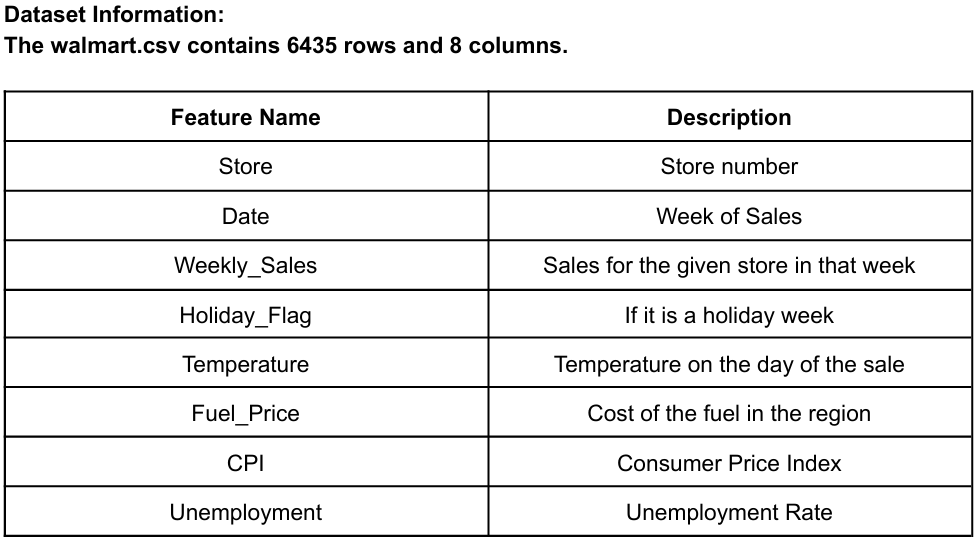

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [20]:
from google.colab import drive
drive.mount('/content/mydrive')

Drive already mounted at /content/mydrive; to attempt to forcibly remount, call drive.mount("/content/mydrive", force_remount=True).


In [21]:
df = pd.read_csv('/content/mydrive/MyDrive/Colab Notebooks/Data/Walmart/Walmart DataSet.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [23]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [24]:
df.replace(['nan','n/a'], np.nan, inplace=True)

In [25]:
#datetime conversion
df['Date'] = pd.to_datetime(df['Date'], format = '%d-%m-%Y')
df = df.sort_values('Date').reset_index(drop=True)

In [26]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
2,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
3,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,6435.0,23.0,1.0,12.0,23.0,34.0,45.0,12.988182
Date,6435,2011-06-17 00:00:00.000000256,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,6435.0,1046964.877562,209986.25,553350.105,960746.04,1420158.66,3818686.45,564366.622054
Holiday_Flag,6435.0,0.06993,0.0,0.0,0.0,0.0,1.0,0.255049
Temperature,6435.0,60.663782,-2.06,47.46,62.67,74.94,100.14,18.444933
Fuel_Price,6435.0,3.358607,2.472,2.933,3.445,3.735,4.468,0.45902
CPI,6435.0,171.578394,126.064,131.735,182.616521,212.743293,227.232807,39.356712
Unemployment,6435.0,7.999151,3.879,6.891,7.874,8.622,14.313,1.875885


In [29]:
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of Unique Stores: {df['Store'].nunique()}")
print(f"Number of Records per Store: \n{df.groupby('Store').size().describe()}")
total_days= (df['Date'].max()-df['Date'].min()).days
print(f'Dataset contain: {total_days} days')


Date Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of Unique Stores: 45
Number of Records per Store: 
count     45.0
mean     143.0
std        0.0
min      143.0
25%      143.0
50%      143.0
75%      143.0
max      143.0
dtype: float64
Dataset contain: 994 days


In [30]:
df.Holiday_Flag.value_counts()

,count
Holiday_Flag,
0,5985
1,450


In [31]:
df[(df['Holiday_Flag']==1)] \
.sort_values('Date')

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
45,8,2010-02-12,994801.40,1,33.34,2.548,214.621419,6.299
70,11,2010-02-12,1574684.08,1,48.01,2.548,214.574792,7.368
71,36,2010-02-12,469563.70,1,46.11,2.539,209.997021,8.554
72,42,2010-02-12,575709.96,1,49.96,2.828,126.496258,9.765
73,14,2010-02-12,1704218.84,1,27.73,2.773,181.982317,8.992
...,...,...,...,...,...,...,...,...
6092,28,2012-09-07,1469693.99,1,88.52,4.124,130.932548,10.926
6093,45,2012-09-07,766512.66,1,75.70,3.911,191.577676,8.684
6094,16,2012-09-07,537138.58,1,60.09,3.596,198.095048,6.061
6084,43,2012-09-07,663814.18,1,84.99,3.730,213.799099,9.285


Four holidays fall within the following weeks in the dataset (not all holidays are in the data):

Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13

Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13

Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13

Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

In [59]:
out_col = df.groupby('Store').apply(lambda i : i['Weekly_Sales']. corr(i['Unemployment'])).reset_index(name = 'sales_unemp_corr')
out_col.sort_values(by = 'sales_unemp_corr').head(5).reset_index(drop = True)

,Store,sales_unemp_corr
0,38,-0.785290
1,44,-0.780076
2,39,-0.384681
3,42,-0.356355
4,41,-0.350630


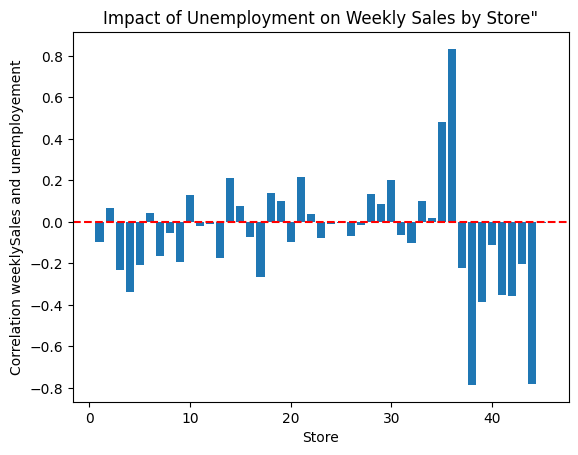

In [33]:
from matplotlib.lines import lineStyles
plt.bar(out_col['Store'],out_col['sales_unemp_corr'], label='correlation')
plt.axhline(0, linestyle = '--', color = 'red')
plt.title('Impact of Unemployment on Weekly Sales by Store"')
plt.xlabel('Store')
plt.ylabel('Correlation weeklySales and unemployement')
plt.show()

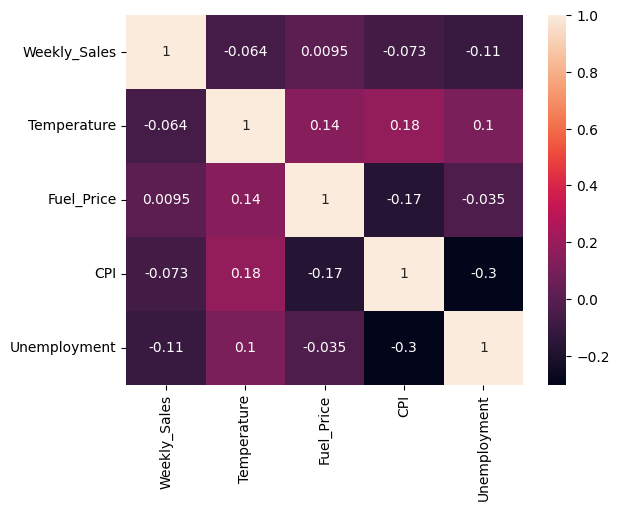

In [85]:

features = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

sns.heatmap(df[features].corr(), annot=True,)

plt.show()

`Weekkly sales and Unemployement shows the **negative corelation** that means if weekly sales increase the unemployemnt rate decrease automatically because of heavy demand and supply`

##### **Conlcusion 1:**

*   ***Weekly Sales*** are `negatively affected` by ***unemployement rate*** *(The correlation matrix shows the correlation of -0.11)*, which means that wherever the `unemployement rate is high the weekly sale is low`

*   Other features which has negative correlation with weekly sales are Tempertaure and CPI. Which shows that where temperature and CPI are high the weekly sales are slightly low, but these negative correlations are very weak.

*   Fuel price has a weak positive correlation with the weekly sales.





In [87]:
#Checking which store is effected most by unemployment

x = df.groupby('Store')['Unemployment'].mean()
x.sort_values(ascending=False).head()

,Unemployment
Store,
12,13.116483
38,13.116483
28,13.116483
43,9.934804
34,9.934804


`Store number 12, 38, & 28 are effected most by the unemployment rate with highest average unemployment of 13.116483`

In [64]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

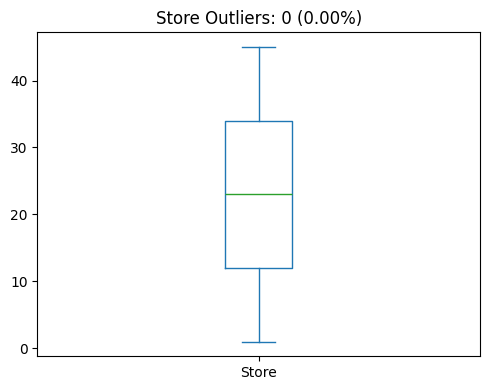

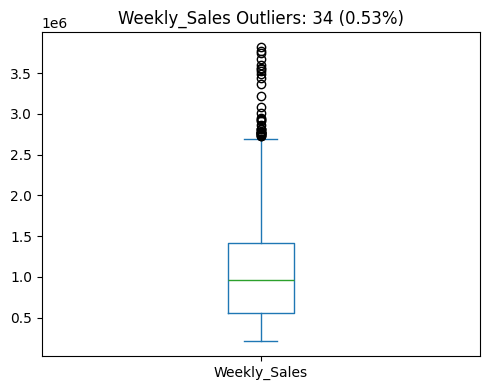

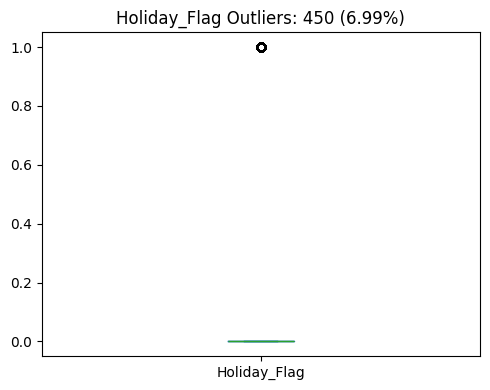

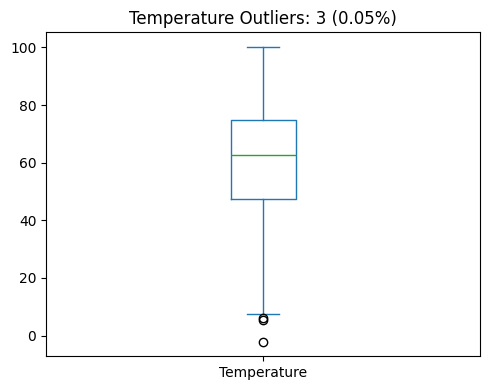

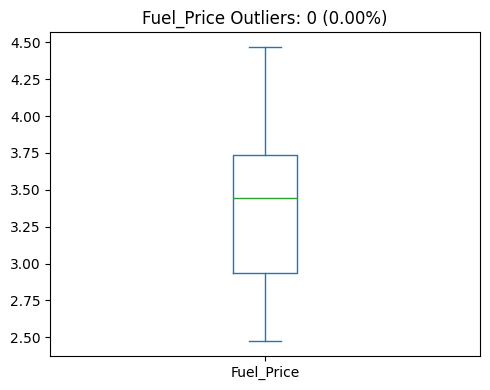

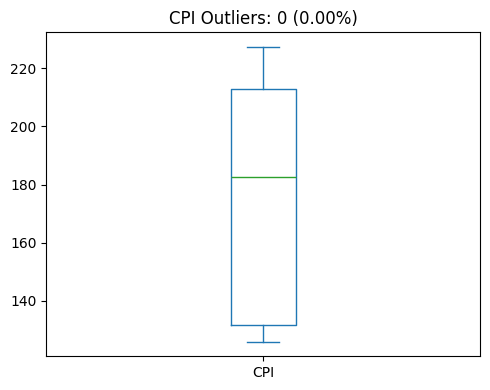

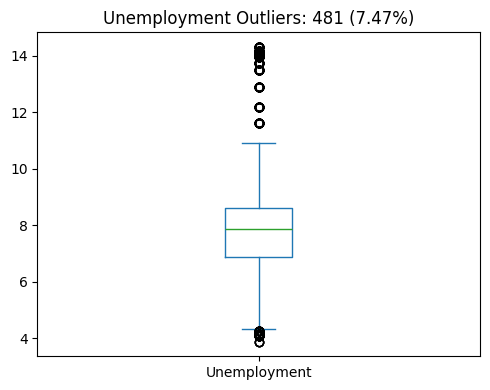

In [70]:
import matplotlib.pyplot as plt

# Check against original df's numeric columns
for col in df.select_dtypes(include='number').columns:

    # 1. Calculate IQR boundaries
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1

    up_limit = q3 + (1.5 * IQR)
    low_limit = q1 - (1.5 * IQR)

    # 2. Extract outliers
    outliers = df[(df[col] > up_limit) | (df[col] < low_limit)]

    # 3. Generate individual boxplots with percentage calculations
    plt.figure(figsize=(5, 4))

    # Using boxplot directly on the column
    df[col].plot(kind='box')

    plt.title(f'{col} Outliers: {len(outliers)} ({len(outliers)/len(df):.2%})')
    plt.tight_layout()
    plt.show()


`Outliers are present in 'Weekly_Sales', 'Holiday_Flag', 'Temperature','Unemployment' columns but these are real, meaningful events, not errors. Removing them would lose valuable patterns.`

In [71]:
store = int(input('enter the store number to get the weekly sale of that store : '))
data = df[df['Store']== store]
weekly_sale = data[['Date','Weekly_Sales']].reset_index(drop = True)
print('-' * 80)
print(f'weekly sales for store {store}')
print(weekly_sale.head(5)\
      .sort_values(by ='Weekly_Sales', ascending = False))
print('-' * 80)
print(f'Total Sales for store {store} : {data['Weekly_Sales'].sum()/1000000:.2f}Millions')


enter the store number to get the weekly sale of that store : 3
--------------------------------------------------------------------------------
weekly sales for store 3
        Date  Weekly_Sales
0 2010-02-05     461622.22
2 2010-02-19     421642.19
1 2010-02-12     420728.96
4 2010-03-05     415202.04
3 2010-02-26     407204.86
--------------------------------------------------------------------------------
Total Sales for store 3 : 57.59Millions


### **1b. If the weekly sales show a seasonal trend, when and what could be the reason?**

`B. To check the seasonality in the data, we will plot a graph between the Date and the Weekly Sales. Once we find the seasonality we will check the pattern of data around that time of the year. `

In [91]:
sale_by_store_mean = df.groupby('Date')['Weekly_Sales'].mean()
sale_by_store_mean


,Weekly_Sales
Date,
2010-02-05,1.105572e+06
2010-02-12,1.074148e+06
2010-02-19,1.072822e+06
2010-02-26,9.770794e+05
2010-03-05,1.041588e+06
...,...
2012-09-28,9.718867e+05
2012-10-05,1.057036e+06
2012-10-12,1.025078e+06


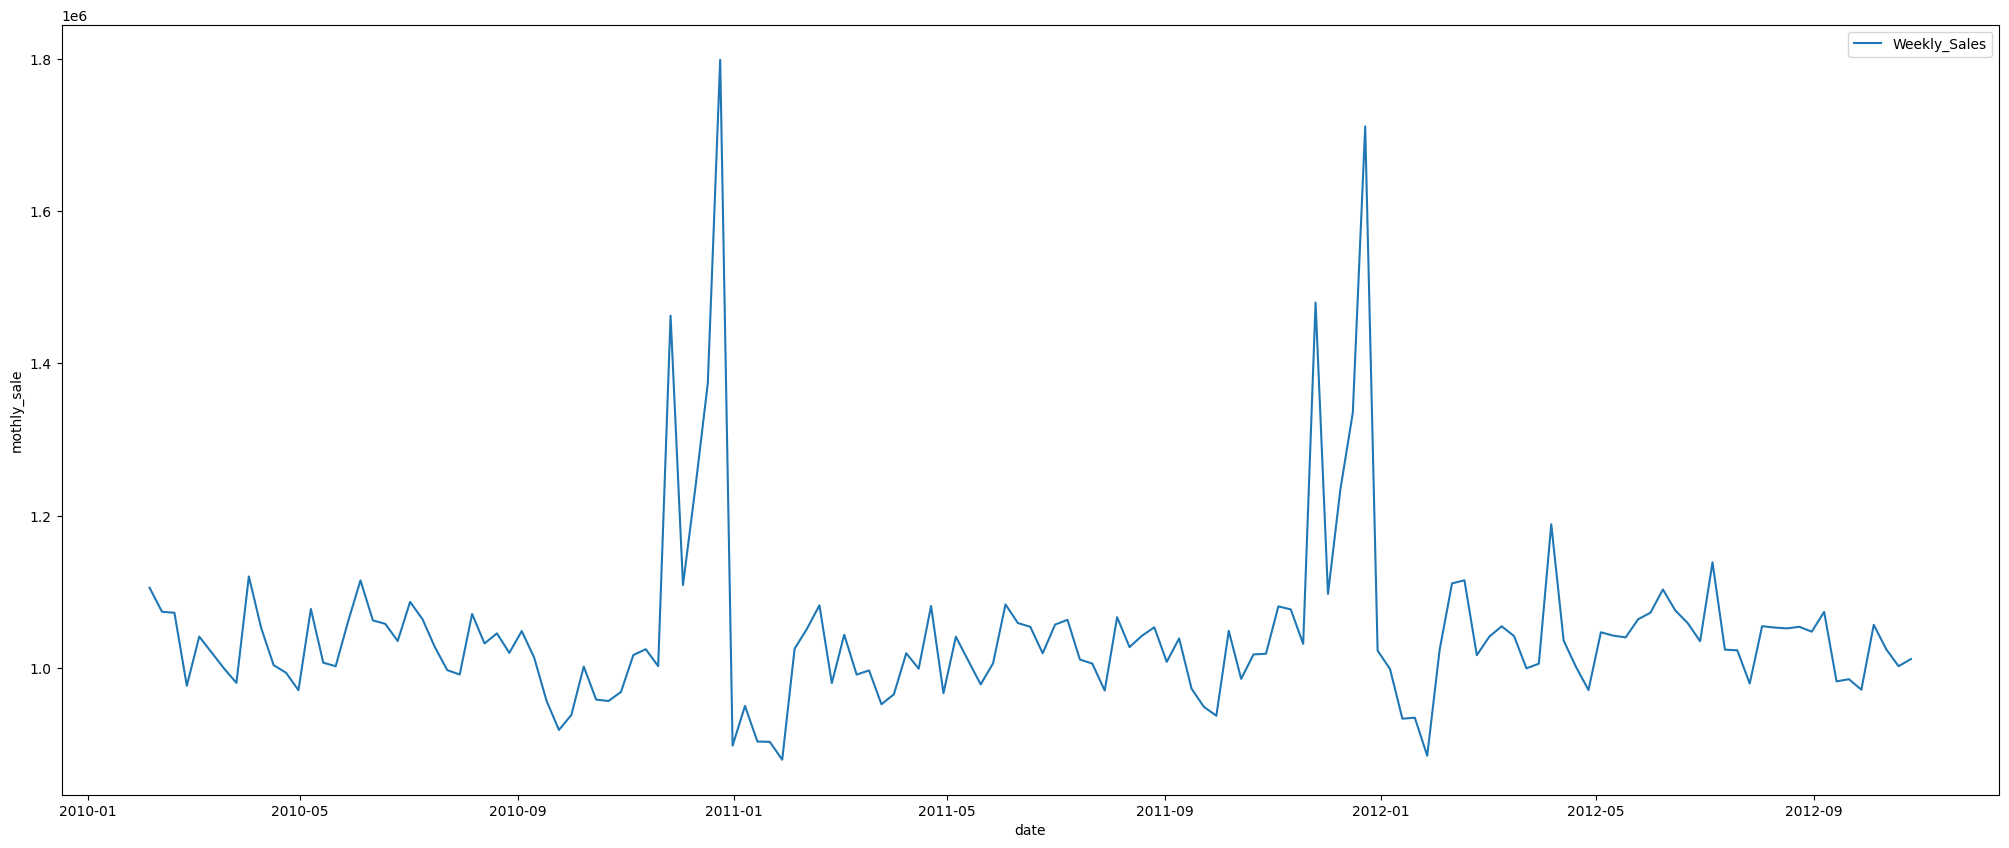

In [97]:
plt.figure(figsize = (25,10))
plt.plot(sale_by_store_mean, label = 'Weekly_Sales')

plt.xlabel('date')
plt.ylabel('mothly_sale')
plt.legend()

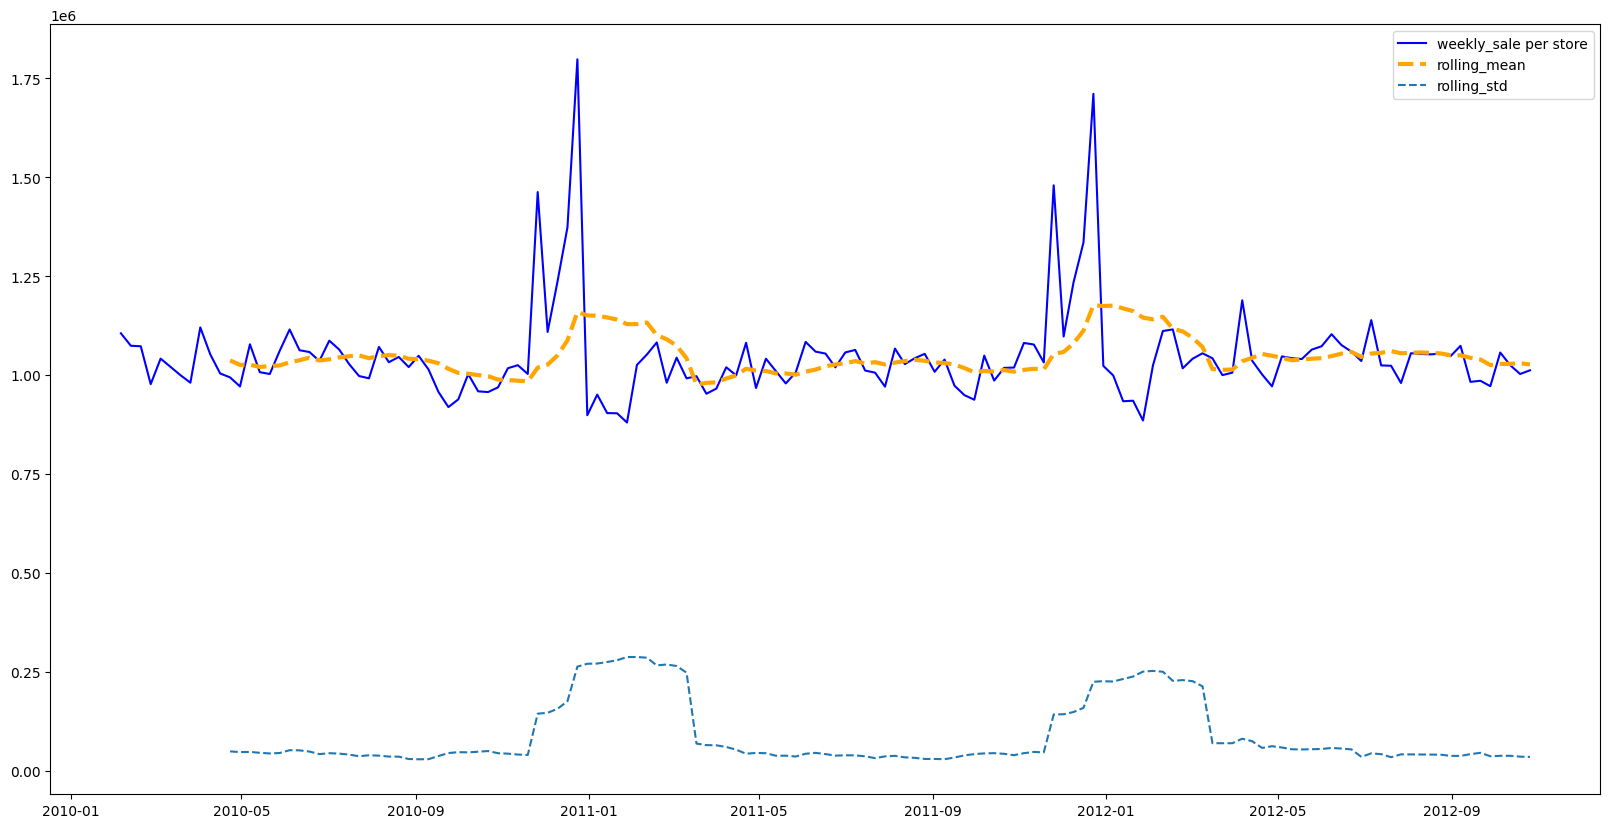

In [93]:
#to check seasonality and trend

rolling_mean = sale_by_store_mean.rolling(window = 12).mean()
rolling_std = sale_by_store_mean.rolling(window= 12).std()

plt.figure( figsize = (20,10), )
plt.plot(sale_by_store_mean, color = 'blue', label = 'weekly_sale per store')
plt.plot(rolling_mean, color = 'orange', linewidth= 3, linestyle = '--', label = 'rolling_mean' )
plt.plot(rolling_std, linestyle = '--', label = 'rolling_std')
plt.legend()

In [76]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

Figure(640x480)


<Figure size 2000x1500 with 0 Axes>

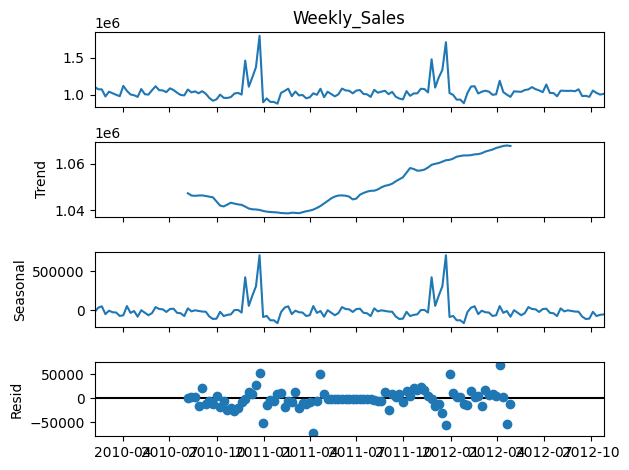

In [77]:
plt.figure(figsize=(20,15))
decompose = seasonal_decompose(sale_by_store_mean)
print(decompose.plot())
plt.show()

In [94]:
result = adfuller(sale_by_store_mean)
print(f'{result[1]:4f}')  #data is stationary


0.000000


`Conclusion 2:`
Yes Weekly Sales do show the seasonal effect from **Mid of November to End of December every year**

In [ ]:
# Finding reason for seasonality in the data by checking the pattern during November and December each year.

seasonal_data = data[(data['Date'].dt.month == 11) | (data['Date'].dt.month == 12)]
seasonal_data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
39,1,2010-11-05,1551659.28,0,58.74,2.689,211.956394,7.838
40,1,2010-11-12,1494479.49,0,59.61,2.728,212.003944,7.838
41,1,2010-11-19,1483784.18,0,51.41,2.771,211.889674,7.838
42,1,2010-11-26,1955624.11,1,64.52,2.735,211.748433,7.838
43,1,2010-12-03,1548033.78,0,49.27,2.708,211.607193,7.838
...,...,...,...,...,...,...,...,...
6387,45,2011-12-02,875699.81,0,50.19,3.452,188.502435,8.523
6388,45,2011-12-09,957155.31,0,46.57,3.415,188.654469,8.523
6389,45,2011-12-16,1078905.68,0,39.93,3.413,188.797935,8.523
6390,45,2011-12-23,1521957.99,0,42.27,3.389,188.929975,8.523


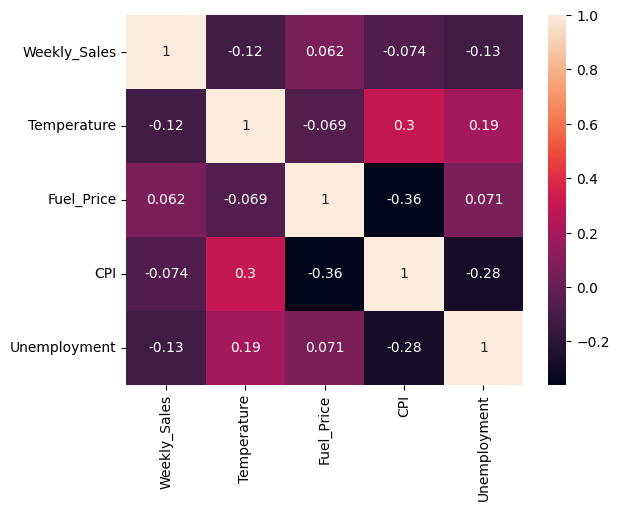

In [ ]:
#Checking the correlation of different features with the weekly sales during November and December each year.

features1 = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

sns.heatmap(seasonal_data[features1].corr(), annot=True,)

plt.show()


### Reason of Seasonality:
- In the above plot we can see a `highly negative correlation of 0.12` between Weekly Sales and Temparature, which clearly means `during certain time in year i.e. Mid November to End of December the Temperature drops and Sale increases`.

- We can also see a `highly negative correlation of 0.13` between Weekly Sales and Unemployment during mentioned Period of time. Which means `during this time the rate of unemployment reduces and hence it leads to increased sales`.

### **1c. Does temperature affect the weekly sales in any manner?**

In [98]:
temp_corr = df['Temperature'].corr(df['Weekly_Sales'])
print(f"Correlation between Temperature and Weekly Sales: {temp_corr:.2f}")

Correlation between Temperature and Weekly Sales: -0.06


C. *Yes* the Temperature affects the weekly Sales, in `Negative manner` the correlation is of `-0.06`.


 As we have already seen the effect of Temperature on weekly sales in previous exploration that it shows a **Negative Correlation of 6.4** with Weekly Sales. We have also seen previously that during the seasonal effect on our weekly Sales which is around *November and December each year* temprature has *Even Higher Negative Correlation* with the weekly sales which is of **0.12**.



### **1d. How is the Consumer Price index affecting the weekly sales of various stores?**

In [99]:
cpi_corr = df['CPI'].corr(df['Weekly_Sales'])
print(f"Correlation between CPI and Weekly Sales: {cpi_corr:.2f}")

Correlation between CPI and Weekly Sales: -0.07


#### D. Yes, *CPI* affects *Weekly Sales*, `Negatively`. The correlation between CPI and Weekly sales show a negative correlation of `-0.07`

`Conclusion 2:`
Yes Weekly Sales do show the seasonal effect from **Mid of November to End of December every year**

### **1e. Top performing stores according to the historical data.**

In [102]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
2,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
3,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


In [115]:
Top_performing_store = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending = False)
Top_performing_store.head(1)

,Weekly_Sales
Store,
20,2.107677e+06


### Top performing stores are `store 20` with average weekly sales of `Rs. 2107677.`

### **1f. The worst performing store, and how significant is the difference between the highest and lowest performing stores.**

In [120]:
worst_performing_store = Top_performing_store.tail(1)
worst_performing_store

,Weekly_Sales
Store,
33,259861.692028


### Least performing stores are `store 33` with average weekly sales of `Rs. 259861.`

In [122]:
diff = Top_performing_store.values[0] - worst_performing_store.values[0]
print(f"Difference between highest and lowest performing stores: {diff:.2f}")

Difference between highest and lowest performing stores: 1847815.18


## **2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.**

In [ ]:
# due to seasonality present we will use sarimax model to forcast weekly sales for next 12 weeks

In [129]:
df.Store.unique().max()

np.int64(45)

In [149]:
#forcasting for particular store
store = int(input('enter the store number(1-45) you want to forcast weekly sales'))
while(store<1 or store>45):
  store = int(input('enter the valid store number(1-45) you want to forcast weekly sales'))

filtered_store = df[df['Store']== store]
print('--'*50)
print(f'weekly sales for store -> {store} : ')
cleaned_df = filtered_store.set_index('Date', drop= True)['Weekly_Sales']
cleaned_df


enter the store number(1-45) you want to forcast weekly sales3
----------------------------------------------------------------------------------------------------
weekly sales for store -> 3 : 


,Weekly_Sales
Date,
2010-02-05,461622.22
2010-02-12,420728.96
2010-02-19,421642.19
2010-02-26,407204.86
2010-03-05,415202.04
...,...
2012-09-28,389813.02
2012-10-05,443557.65
2012-10-12,410804.39


<Axes: xlabel='Date'>

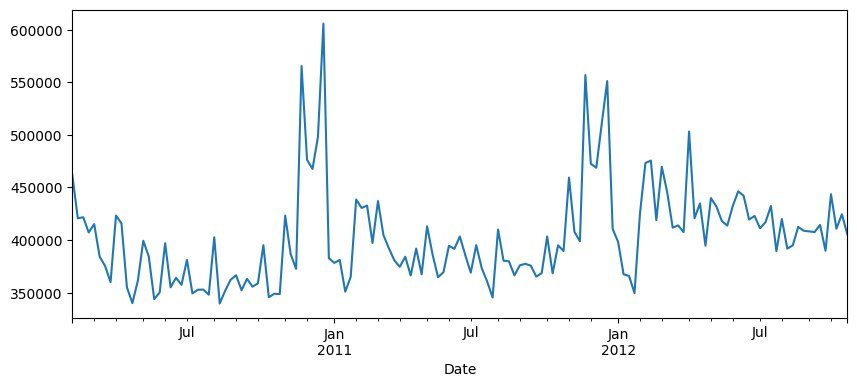

In [153]:
cleaned_df.plot(figsize=(10,4))

In [158]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(cleaned_df.dropna())
print(f'p-value: {result[1]}')

p-value: 0.03840926179831238


In [ ]:
# using auto ar